# DECODE - Fit SMLM Data
The purpose of this notebook is to demonstrate the fitting procedure for a pretrained model.
Please be advised to have a read of the Introduction notebook first.

Notebook has been modified for data from Janelia Hess Lab PALM instrument. 

In [4]:
import sys

import decode
import decode.utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import os
from wip_util import zero_pad_index

print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

DECODE version: vINVALID-recent-0.10.2


## Set parameters
Set device for inference (i.e. CUDA vs. CPU, for our setup inference on the CPU is about 10 times slower). If you fit on CPU though, you may want to change the number of threads if you have a big machine (see below).

In [5]:
device = 'cuda:0'  # or 'cpu', or you change cuda device index
threads = 3  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 0  # number of workers for data loading. Used a default of 0 for safety. Multiprocessing on windows is sometimes not stable

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if not torch.cuda.is_available():
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

## Specify paths for the model, parameters and frames
If you trained you own model (using the Training notebook) you can specify it's path here.

**Important** If the camera parameters of the training differ from the data which should be fitted (e.g. different EM gain), you can try to use the model anyways, but you must specify them here since we convert to photon units before forwarding through the model.

In [6]:
# here you need to specify the parameters with suffix _run.yaml in your model's output folder (not param_run_in.yaml)

frame_path = r'E:\Cryo-PALM Data for Brian\James processing ASCII and RAW Data files\PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)'
out_path = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2'

frame_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/frames/'
frame_path = r'/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)'
out_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2'

fig_path = os.path.join(out_path, 'figures-2025-06-03')
out_iter_path = os.path.join(out_path, 'processed-2025-06-27')

if not os.path.exists(out_iter_path):
    os.makedirs(out_iter_path)

if not os.path.exists(out_path):
    os.makedirs(out_path)

if not os.path.exists(fig_path):
    os.makedirs(fig_path)

if not os.path.exists(frame_path):
    os.makedirs(frame_path)
    
model_path = r'D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-16\decode_model_0.pt'
param_path = r'D:\Janelia_slm_data\models\network_CMOS_C13440_20CU\2025-05-01-d\params.yaml'

model_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/models/2025-06-27-2class-c//decode_model_0.pt'
param_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/models/2025-06-27-2class-c//params.yaml'

emitters_name = os.path.join(out_path, 'emitter.csv')

'''
# specify camera parameters of tiffs
meta = {
    'Camera': {
        'baseline': 398.6,
        'e_per_adu': 5.0,
        'em_gain': 50.0,
        'spur_noise': 0.0015  # if you don't know, you can set this to 0.
    }
}'
'''

"\n# specify camera parameters of tiffs\nmeta = {\n    'Camera': {\n        'baseline': 398.6,\n        'e_per_adu': 5.0,\n        'em_gain': 50.0,\n        'spur_noise': 0.0015  # if you don't know, you can set this to 0.\n    }\n}'\n"

## Load Parameters and Model
Specify Post-Processing as by the parameter file you trained the model with

In [7]:
param = decode.utils.param_io.load_params(param_path)
model = decode.neuralfitter.models.SigmaMUNet.parse(param)
model = decode.utils.model_io.LoadSaveModel(model,
                                            input_file=model_path,
                                            output_file=None).load_init(device=device)

Model instantiated.
Model SHA-1 hash: 729020a4849b604e0fb98e4828fa986b4d318f27
Loaded pretrained model: /home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/models/2025-06-27-2class-c/decode_model_0.pt


In [8]:
# overwrite camera
#param = decode.utils.param_io.autofill_dict(meta['Camera'], param.to_dict(), mode_missing='include')
#param = decode.utils.param_io.RecursiveNamespace(**param)

## Load and Process Frames
Load TIFF file.
Change only needed if you load a custom tif file.
Note that the TIFF loader will auto-load and concatenate tiff files
that are consecutive and share
the same meta data. For example specifying `dummy.tif` will also load  `dummy_0.tif, dummy_1.tif` if present in the
same folder.
If you have single page tiff files, you can also specify a folder.

In [9]:
from skimage.io import imread
import glob
from tqdm import tqdm

frames_per_iter = 250 
start_iter = 0
end_iter = 10

In [10]:
def get_frames_name(id):
    return rf'{frame_path}/3DPALM488nm_Iter_{zero_pad_index(id, 4)}_0001_ch0_CAM1_stack0000_405nm_0000000msec_*msecAbs_000x_000y_000z_0001t.tif'

def load_frames(id):
    #print(f"loading frames for id: {id}")
    frames_pattern = rf'{frame_path}/3DPALM488nm_Iter_{zero_pad_index(id, 4)}_0001_ch0_CAM1_stack0000_405nm_0000000msec_*msecAbs_000x_000y_000z_0001t.tif'
    #frames_pattern = rf'{frame_path}/*.tif'
    print(frame_path)
    frames_name = glob.glob(frames_pattern)
    frames_name = glob.glob(frames_pattern)
    print('frames name',frames_name)
    if frames_name:
        return imread(frames_name[0])
    else:
        print(f"no frames found for id: {id}")
        return None

# get a single 'iter' used for setting up the model
frames = np.concatenate([load_frames(i) for i in tqdm(range(start_iter, start_iter+1))], axis=0)
print(f"Loaded frames shape: {frames.shape}")

  0%|          | 0/1 [00:00<?, ?it/s]

/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)
frames name ['/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)/3DPALM488nm_Iter_0000_0001_ch0_CAM1_stack0000_405nm_0000000msec_0003753720msecAbs_000x_000y_000z_0001t.tif']


100%|██████████| 1/1 [00:06<00:00,  6.56s/it]

Loaded frames shape: (250, 800, 800)


In [11]:

camera = decode.simulation.camera.Photon2Camera.parse(param)
camera.device = 'cpu'


Frames shape: (250, 800, 800)


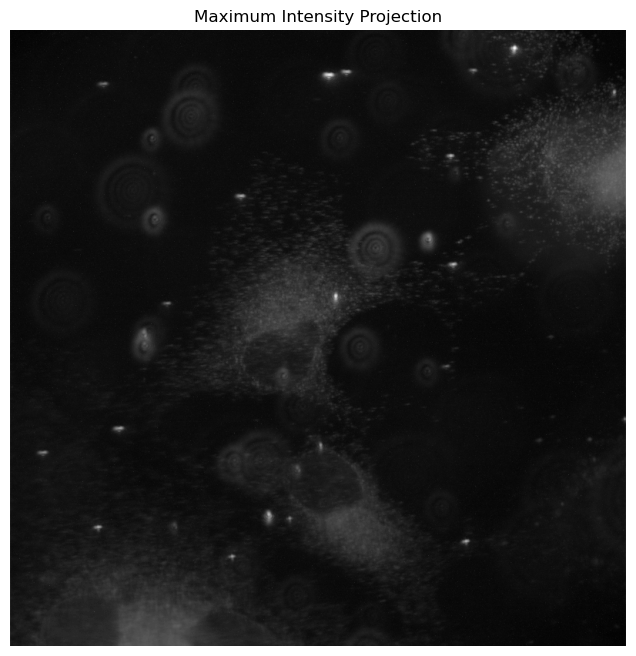

In [12]:

transpose_frames = False 
## switch x and y axis to be consistent with SMAP??  TODO: Look into this further and make sure image is still consistent with calibration....
if transpose_frames:
    frames = frames.transpose(0, 2, 1)

print(f"Frames shape: {frames.shape}")


# Compute maximum intensity projection (MIP)
max_projection = np.log1p(np.max(frames, axis=0))  # Collapse along depth
# Display the MIP using matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(max_projection, cmap='gray')
plt.axis("off")
plt.title("Maximum Intensity Projection")
plt.show()


In [13]:
#  create a small reference set of frames that is used to get sizes from in some calls
frames_ = torch.tensor(frames[:10].astype('float32'), dtype=torch.float32, device=device)
frames_.shape
frames_[0]

tensor([[144., 141., 134.,  ..., 142., 167., 150.],
        [154., 139., 129.,  ..., 138., 124., 145.],
        [142., 138., 142.,  ..., 144., 155., 145.],
        ...,
        [281., 204., 193.,  ..., 143., 137., 160.],
        [288., 229., 188.,  ..., 135., 143., 169.],
        [286., 185., 206.,  ..., 139., 135., 157.]], device='cuda:0')

## Set Up Pre- and Post-Processing
In the following we will set up the processing pipeline.

### Frame-Processing
**WARNING: Mirror2D** Depending on your specific camera setup you need to modify the following pipeline. In our case (using an EM-CCD camera) the beads are acquired without EM-Gain, while the experimental frames were acquired with EM-Gain. For our camera, due to some hardware specifics, EM-Gain enabled will lead the frames to be mirrored in the last dimension. Since the trained model and the experimental frames need to be consistent with respect to the PSF, we account for this mirroring by `Mirror2D(dims=-1)`.

Depending on your individual camera you might be able to omit this. Particularly if you are using a sCMOS camera.

**AutoCenterCrop** Due to peculiarities of training a Deep Learning model, the size of the input frame is slightly restricted. In our case the input frame size must be in multitudes of 8 per edge. For this reason we ***center crop*** the frame to a size that satisfies this requirement. That means an input frame of size 34 x 41 would be cropped to 32 x 40 and only fitted in this region. If you want to use a non-destructive method you could replace `AutoCenterCrop` by `AutoPad`, however this could lead to a distortion at the frame border which is why we recommend `AutoCenterCrop`.

In [14]:
# setup frame processing as by the parameter with which the model was trained
frame_proc = decode.neuralfitter.utils.processing.TransformSequence([
    decode.neuralfitter.utils.processing.wrap_callable(camera.backward),
    decode.neuralfitter.frame_processing.AutoCenterCrop(8),
    #decode.neuralfitter.frame_processing.Mirror2D(dims=-1),  # WARNING: You might need to comment this line out. see above
    decode.neuralfitter.scale_transform.AmplitudeRescale.parse(param)
])

# determine extent of frame and its dimension after frame_processing
size_procced = decode.neuralfitter.frame_processing.get_frame_extent(frames_.unsqueeze(1).size(), frame_proc.forward)  # frame size after processing
frame_extent = ((-0.5, size_procced[-2] - 0.5), (-0.5, size_procced[-1] - 0.5))


# Setup post-processing
# It's a sequence of backscaling, relative to abs. coord conversion and frame2emitter conversion
post_proc = decode.neuralfitter.utils.processing.TransformSequence([

    decode.neuralfitter.scale_transform.InverseParamListRescale.parse(param),

    decode.neuralfitter.coord_transform.Offset2Coordinate(xextent=frame_extent[0],
                                                          yextent=frame_extent[1],
                                                          img_shape=size_procced[-2:]),

    decode.neuralfitter.post_processing.SpatialIntegration(raw_th=0.1,
                                                          xy_unit='px',
                                                          px_size=param.Camera.px_size)


])

/home/bnorthan/mambaforge/envs/decode_env/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Fit the Data

In [23]:


infer = decode.neuralfitter.Infer(model=model, ch_in=param.HyperParameter.channels_in,
                                  frame_proc=frame_proc, post_proc=post_proc,
                                  device=device, num_workers=worker)

infer.batch_size = 1

start_iter = 760
end_iter = 780

frames_per_iter = 250

for i in range(start_iter, end_iter):
    print(f"Processing iteration {i}")
    frames = load_frames(i)
    frames = torch.tensor(frames.astype('float32'), dtype=torch.float32, device=device) 
    print(f"Frames shape: {frames.shape}")
    emitter = infer.forward(frames)
    emitter.frame_ix += i * frames_per_iter
    print(f"Emitter: {emitter}")
    out_h5 = os.path.join(out_iter_path, f'iter_{i}.h5')
    print(out_h5)
    emitter.save(out_h5)

Processing iteration 760
/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)
frames name ['/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)/3DPALM488nm_Iter_0760_0001_ch0_CAM1_stack0000_405nm_0000000msec_0153036975msecAbs_000x_000y_000z_0001t.tif']
Frames shape: torch.Size([250, 800, 800])


100%|██████████| 250/250 [02:12<00:00,  1.89it/s]


Emitter: EmitterSet
::num emitters: 198495
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 190000 - 190249
::spanned volume: [-4.3134311e-01 -6.2127316e-01 -1.2746110e+03] - [ 799.5326  799.476  1251.4574]
/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/processed-2025-06-27/iter_760.h5
Processing iteration 761
/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)
frames name ['/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)/3DPALM488nm_Iter_0761_0001_ch0_CAM1_stack0000_405nm_0000000msec_0153232957msecAbs_000x_000y_000z_0001t.tif']
Frames shape: torch.Size([250, 800, 800])


100%|██████████| 250/250 [02:12<00:00,  1.89it/s]


Emitter: EmitterSet
::num emitters: 213701
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 190250 - 190499
::spanned volume: [-5.0029707e-01 -6.5374386e-01 -1.2596906e+03] - [ 799.5455  799.4909 1241.3274]
/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/processed-2025-06-27/iter_761.h5
Processing iteration 762
/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)
frames name ['/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)/3DPALM488nm_Iter_0762_0001_ch0_CAM1_stack0000_405nm_0000000msec_0153429633msecAbs_000x_000y_000z_0001t.tif']
Frames shape: torch.Size([250, 800, 800])


...

Emitter: EmitterSet
::num emitters: 168422
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 194250 - 194499
::spanned volume: [-4.7092715e-01 -6.2748945e-01 -1.2518857e+03] - [ 799.4487   799.52545 1240.8419 ]
/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/processed-2025-06-27/iter_777.h5
Processing iteration 778
/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)
frames name ['/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)/3DPALM488nm_Iter_0778_0001_ch0_CAM1_stack0000_405nm_0000000msec_0156571406msecAbs_000x_000y_000z_0001t.tif']
Frames shape: torch.Size([250, 800, 800])


100%|██████████| 250/250 [02:12<00:00,  1.88it/s]


Emitter: EmitterSet
::num emitters: 166823
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 194500 - 194749
::spanned volume: [-5.3828454e-01 -6.2787938e-01 -1.2604702e+03] - [ 799.43     799.50964 1233.7716 ]
/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/processed-2025-06-27/iter_778.h5
Processing iteration 779
/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)
frames name ['/media/bnorthan/LaCie/Cryo-PALM Data for Brian/James processing ASCII and RAW Data files/PALM_Run2_slab_0001_488nm_Frames_(Processed_Slab)/3DPALM488nm_Iter_0779_0001_ch0_CAM1_stack0000_405nm_0000000msec_0156768023msecAbs_000x_000y_000z_0001t.tif']
Frames shape: torch.Size([250, 800, 800])


100%|██████████| 250/250 [02:13<00:00,  1.87it/s]

Emitter: EmitterSet
::num emitters: 169367
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 194750 - 194999
::spanned volume: [-4.6193099e-01 -6.4876926e-01 -1.2471600e+03] - [ 799.4739   799.48645 1238.4989 ]
/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/processed-2025-06-27/iter_779.h5


In [13]:
out_csv = os.path.join(out_path, f'emitters_{start_iter}_{end_iter}_filtered.csv')
print(out_csv)
emitter.save(out_csv)

/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/emitters_645_647_filtered.csv
